# Notebook 04  .  Analyse sémantique (LDA, CamemBERT, similarité cosinus)

## Objectif

Ce notebook explore la **structure thématique** des discours VSS à l'Assemblée Nationale à l'aide de méthodes de NLP non supervisé. L'objectif est double :

1. **Identifier les thématiques latentes** dans les discours VSS via le topic modeling (LDA), et notamment détecter l'émergence éventuelle d'un "topic identitaire/migratoire".
2. **Mesurer la proximité sémantique** entre les blocs idéologiques au fil du temps, via des plongements (embeddings) CamemBERT et la similarité cosinus.

## Approche méthodologique

### LDA  .  Bonnes pratiques suivies
Conformément à la littérature (Blei et al. 2003 ; Mimno et al. 2011 ; Röder et al. 2015), nous adoptons une démarche rigoureuse pour le topic modeling :

1. **Pré-traitement approfondi** : lemmatisation, suppression des stopwords enrichis du bruit parlementaire, détection de bigrammes/trigrammes fréquents, filtrage des extrêmes du dictionnaire.
2. **Sélection du nombre de topics par cohérence** : au lieu de fixer arbitrairement *k*, on entraîne des modèles pour *k* ∈ {3, 5, 7, 10, 13, 15, 20, 25} et on sélectionne celui qui maximise le score de cohérence *u_mass* (Mimno et al. 2011), confirmé par une inspection du *c_v* (Röder et al. 2015).
3. **Optimisation des hyperparamètres** : on teste les combinaisons `alpha` × `eta` parmi `{'symmetric', 'asymmetric', 'auto'}` pour trouver la configuration la plus cohérente.
4. **Validation qualitative** : inspection humaine des mots-clés de chaque topic, vérification de la non-redondance, et analyse de la perplexité.

### Embeddings contextuels (CamemBERT)
On utilise CamemBERT-base (Martin et al. 2020) pour obtenir des représentations vectorielles de 768 dimensions capturant le sens contextuel des prises de parole, à la différence de Word2Vec qui opère au niveau du mot isolé.

## Entrées
- `df_vss_propre.pkl` (notebook 02)

## Sorties
- Graphiques de cohérence, topics, convergence sémantique
- `df_vss_embeddings.pkl` (vecteurs CamemBERT pré-calculés)
- `lda_best_model.pkl` (meilleur modèle LDA sauvegardé)

---
## Partie A  .  Topic Modeling (LDA)
---

### A.1 Imports et chargement des données

In [1]:
from config import *
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re, os, pickle, warnings
from tqdm import tqdm

from gensim import corpora, models
from gensim.models import LdaModel, LdaMulticore, Phrases
from gensim.models.coherencemodel import CoherenceModel

import nltk
from nltk.corpus import stopwords
from nltk.stem.snowball import FrenchStemmer
nltk.download('stopwords', quiet=True)

warnings.filterwarnings('ignore')
stemmer = FrenchStemmer()

# Chargement
# Chemin identique au Testfile original
chemin_propre = "/home/onyxia/work/projet_eco_socio/df_vss_propre.pkl"
if not os.path.exists(chemin_propre):
    chemin_propre = CHEMIN_DF_VSS_PROPRE
df_vss = pd.read_pickle(chemin_propre)
df_vss['date'] = pd.to_datetime(df_vss['date'])
df_blocs = df_vss.dropna(subset=['bloc']).copy()

print(f" {len(df_blocs)} prises de parole chargées ({df_blocs['bloc'].nunique()} blocs).")

# Style graphique pastel, polices fines, epure
import matplotlib.pyplot as plt
import matplotlib as mpl

PALETTE_PASTEL = ["#A8D8EA", "#AA96DA", "#FCBAD3", "#FFFFD2", "#B5EAD7",
                  "#C7CEEA", "#FFB7B2", "#E2F0CB", "#FFDAC1", "#B5B8FF"]

COULEURS_BLOCS = {
    "Extrême Droite":        "#E88D9A",
    "Droite Traditionnelle": "#7BAFD4",
    "Centre":                "#F2CC8F",
    "Gauche Modérée":        "#81B29A",
    "Gauche Radicale":       "#D4A5A5",
}

ORDRE_BLOCS = ["Extrême Droite", "Droite Traditionnelle", "Centre",
               "Gauche Modérée", "Gauche Radicale"]

plt.rcParams.update({
    'font.family': 'sans-serif', 'font.size': 11, 'font.weight': 'light',
    'axes.titlesize': 13, 'axes.titleweight': 'normal',
    'axes.labelsize': 11, 'axes.labelweight': 'light',
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.edgecolor': '#CCCCCC', 'axes.grid': True,
    'grid.alpha': 0.3, 'grid.color': '#DDDDDD',
    'legend.frameon': False, 'legend.fontsize': 9,
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'xtick.color': '#333333', 'ytick.color': '#333333', 'text.color': '#222222',
})


 7815 prises de parole chargées (5 blocs).


### A.2 Pré-traitement textuel approfondi

Le pré-traitement est l'étape la plus critique pour la qualité de la LDA (Schofield et al. 2017). Un mauvais nettoyage produit des topics bruités et non interprétables.

**Améliorations par rapport à la version précédente :**
- Tokenisation plus fine (suppression des nombres, mots courts ≤ 2 caractères)
- Stopwords enrichis du **bruit parlementaire** (termes procéduraux omniprésents : *monsieur, madame, président, amendement, article, commission*...) et des **mots-clés VSS** (pour éviter le biais circulaire : puisqu'on a filtré par ces mots, ils domineraient tous les topics)
- Détection de **bigrammes** fréquents (ex : *violence_conjugale*, *harcèlement_sexuel*) via le modèle `Phrases` de Gensim, qui capture les expressions multi-mots
- Stemming avec le `FrenchStemmer` de NLTK (Snowball)

In [2]:
# ==========================================================================
# Construction d'une liste de stopwords exhaustive
# ==========================================================================

stop_words = set(stopwords.words('french'))

# Bruit parlementaire (termes omniprésents dans TOUS les débats, pas spécifiques aux VSS)
bruit_parlementaire = {
    # Formules d'adresse et titres
    "monsieur", "madame", "président", "présidente", "ministre",
    "député", "députée", "députés", "collègue", "collègues",
    "secrétaire", "rapporteur", "rapporteure", "orateur",
    # Procédure parlementaire
    "amendement", "amendements", "article", "articles", "alinéa",
    "projet", "proposition", "loi", "texte", "vote", "voter",
    "adopter", "adopté", "adoptée", "séance", "commission",
    "discussion", "débat", "examen", "lecture", "scrutin",
    "hémicycle", "assemblée", "nationale", "gouvernement",
    "groupe", "banc", "bancs", "applaudissements",
    # Verbes procéduraux
    "demander", "proposer", "souhaiter", "permettre", "falloir",
    "devoir", "pouvoir", "vouloir", "savoir", "croire",
    "penser", "dire", "faire", "être", "avoir", "aller",
    # Connecteurs et adverbes fréquents
    "plus", "très", "bien", "tout", "tous", "toute", "toutes",
    "aussi", "donc", "encore", "vraiment", "évidemment",
    "également", "simplement", "effectivement", "certainement",
    "aujourd", "hui", "ici", "puis", "enfin", "ainsi",
    # Quantifieurs
    "premier", "première", "deux", "trois", "quatre", "cinq",
    "million", "milliard", "euro", "euros", "franc", "francs",
}
stop_words.update(bruit_parlementaire)

# Mots-clés VSS : on les retire pour éviter le biais circulaire
# (puisqu'on a filtré les documents PAR ces mots)
mots_vss_a_retirer = {
    "viol", "viols", "violences", "violence", "sexuel", "sexuelle",
    "sexuels", "sexuelles", "sexiste", "sexistes", "harcèlement",
    "agression", "agressions", "conjugal", "conjugale", "conjugales",
    "féminicide", "féminicides", "inceste", "outrage", "discrimination",
    "discriminations", "genre", "sexe", "avortement", "ivg",
    "consentement", "stéréotype", "stéréotypes", "prostitu",
    "prostitution", "proxénétisme", "mutilation", "mutilations",
    "pédocriminalité", "pédophilie", "misogyne", "misogynie",
}
stop_words.update(mots_vss_a_retirer)

print(f"✅ {len(stop_words)} stopwords au total.")

✅ 288 stopwords au total.


In [3]:
def tokeniser_document(texte, stop_words):
    """
    Tokenise et nettoie un texte pour la LDA.

    Étapes :
    1. Mise en minuscule
    2. Suppression de la ponctuation et des nombres
    3. Tokenisation par espaces
    4. Suppression des stopwords et mots courts (≤ 2 caractères)
    5. Stemming
    """
    texte = str(texte).lower()
    texte = re.sub(r'[^a-zàâäéèêëïîôùûüÿçœæ\s]', ' ', texte)  # garder lettres françaises
    texte = re.sub(r'\s+', ' ', texte).strip()

    tokens = [
        stemmer.stem(mot)
        for mot in texte.split()
        if mot not in stop_words and len(mot) > 2
    ]
    return tokens

# Application à tout le corpus
print("Tokenisation du corpus...")
df_blocs['tokens'] = df_blocs['texte'].apply(lambda x: tokeniser_document(x, stop_words))

# Suppression des documents vides
df_blocs = df_blocs[df_blocs['tokens'].apply(len) > 3].copy()
print(f"   {len(df_blocs)} documents après nettoyage (suppression des documents < 4 tokens).")

🔄 Tokenisation du corpus...
   7677 documents après nettoyage (suppression des documents < 4 tokens).


### A.3 Détection de bigrammes

Les bigrammes permettent de capturer des expressions composées (*violence_conjugale*, *droit_femme*, *harcèlement_travail*...) qui portent un sens différent de chaque mot pris isolément. On utilise le modèle `Phrases` de Gensim avec un seuil de fréquence minimale.

In [4]:
# Détection de bigrammes fréquents (seuil = au moins 10 co-occurrences)
bigram_model = Phrases(df_blocs['tokens'].tolist(), min_count=10, threshold=50)
bigram_phraser = bigram_model.freeze()

# Application : les tokens "violence" + "conjugal" deviennent "violence_conjugal"
df_blocs['tokens_bigram'] = df_blocs['tokens'].apply(lambda doc: bigram_phraser[doc])

# Exemples de bigrammes détectés
bigrams_trouves = set()
for doc in df_blocs['tokens_bigram'].head(500):
    for token in doc:
        if '_' in token:
            bigrams_trouves.add(token)

print(f"{len(bigrams_trouves)} bigrammes uniques détectés.")
print(f"   Exemples : {sorted(list(bigrams_trouves))[:15]}")

✅ 504 bigrammes uniques détectés.
   Exemples : ['academ_médecin', 'acte_bucco', 'acte_pénetr', 'acteur_terrain', 'administr_hoc', 'adopt_pléni', 'affair_étranger', 'afriqu_ouest', 'agenc_biomédecin', 'agenc_régional', 'agent_public', 'agir_en', 'agress_sexuel', 'aid_juridictionnel', 'alban_gaillot']


### A.4 Construction du dictionnaire et du corpus

On filtre le dictionnaire pour ne garder que les termes qui apparaissent dans au moins `no_below` documents et dans au plus `no_above` % des documents. Cela élimine :
- Les mots trop rares (hapax, noms propres) → bruit
- Les mots trop fréquents (présents partout) → pas discriminants

In [5]:
# Construction du dictionnaire
textes_pour_lda = df_blocs['tokens_bigram'].tolist()
dictionnaire = corpora.Dictionary(textes_pour_lda)

print(f"   Dictionnaire brut : {len(dictionnaire)} termes uniques.")

# Filtrage des extrêmes
dictionnaire.filter_extremes(
    no_below=10,   # le terme doit apparaître dans au moins 10 documents
    no_above=0.5,  # le terme ne doit pas apparaître dans plus de 50% des documents
    keep_n=5000    # on garde au maximum 5000 termes
)

print(f"   Dictionnaire filtré : {len(dictionnaire)} termes.")

# Construction du corpus BoW (Bag of Words)
corpus = [dictionnaire.doc2bow(doc) for doc in textes_pour_lda]
print(f"   Corpus : {len(corpus)} documents.")

   Dictionnaire brut : 17576 termes uniques.
   Dictionnaire filtré : 5000 termes.
   Corpus : 7677 documents.


### A.5 Sélection du nombre optimal de topics

C'est l'étape la plus importante. On entraîne des modèles LDA pour différentes valeurs de *k* (nombre de topics) et on évalue chaque modèle par son **score de cohérence**.

**Métriques utilisées :**
- **u_mass** (Mimno et al. 2011) : mesure la co-occurrence des mots d'un topic dans le corpus d'entraînement. Plus le score est élevé (moins négatif), meilleur est le topic. C'est la métrique la plus rapide à calculer et la plus recommandée par les auteurs récents (Baeldung, 2025).
- **c_v** (Röder et al. 2015) : mesure basée sur la similarité cosinus de vecteurs de co-occurrence avec fenêtre glissante. Plus robuste mais plus lent. On l'utilise en confirmation.

**Choix de *k*** : on cherche le "coude" de la courbe de cohérence  .  le point après lequel ajouter des topics n'améliore plus significativement la cohérence, ou la dégrade.


In [6]:

chemin_grid_results = os.path.join(DOSSIER_DATAFRAMES, "lda_grid_search_results.pkl")

if os.path.exists(chemin_grid_results):
    with open(chemin_grid_results, 'rb') as f:
        grid_results = pickle.load(f)
    print(f"⏩ Résultats de la grid search chargés depuis le cache ({len(grid_results)} modèles testés).")
else:
    print("🔄 Grid search sur le nombre de topics et les hyperparamètres...")
    print("   Cela peut prendre 10-30 minutes.\n")

    # Plage de topics à tester
    topics_range = [3, 5, 7, 10, 13, 15, 20, 25]

    # Combinaisons d'hyperparamètres à tester
    # alpha contrôle la distribution document-topic (sparse vs dense)
    # eta contrôle la distribution topic-mot (sparse vs dense)
    alpha_values = ['symmetric', 'asymmetric']
    eta_values = ['symmetric', 'auto']

    grid_results = []

    total_combos = len(topics_range) * len(alpha_values) * len(eta_values)
    combo_idx = 0

    for k in topics_range:
        for alpha in alpha_values:
            for eta in eta_values:
                combo_idx += 1
                print(f"   [{combo_idx}/{total_combos}] k={k}, alpha={alpha}, eta={eta}...", end=" ")

                try:
                    model = LdaMulticore(
                        corpus=corpus,
                        id2word=dictionnaire,
                        num_topics=k,
                        alpha=alpha,
                        eta=eta,
                        passes=15,         # nombre de passes sur le corpus
                        iterations=200,    # itérations par document
                        random_state=42,
                        chunksize=500,
                        per_word_topics=True,
                    )

                    # Cohérence u_mass (rapide, basée sur le corpus)
                    cm_umass = CoherenceModel(
                        model=model, corpus=corpus,
                        dictionary=dictionnaire, coherence='u_mass'
                    )
                    score_umass = cm_umass.get_coherence()

                    # Cohérence c_v (plus lente, basée sur les textes)
                    cm_cv = CoherenceModel(
                        model=model, texts=textes_pour_lda,
                        dictionary=dictionnaire, coherence='c_v'
                    )
                    score_cv = cm_cv.get_coherence()

                    # Perplexité (mesure de surprise du modèle face aux données)
                    perplexity = model.log_perplexity(corpus)

                    grid_results.append({
                        'k': k, 'alpha': alpha, 'eta': eta,
                        'coherence_umass': score_umass,
                        'coherence_cv': score_cv,
                        'perplexity': perplexity,
                    })

                    print(f"u_mass={score_umass:.4f}, c_v={score_cv:.4f}")

                except Exception as e:
                    print(f"ERREUR : {e}")
                    continue

    # Sauvegarde
    with open(chemin_grid_results, 'wb') as f:
        pickle.dump(grid_results, f)
    print(f"\nRésultats sauvegardés dans {chemin_grid_results}")

print(f"\n{len(grid_results)} configurations testées au total.")

⏩ Résultats de la grid search chargés depuis le cache (32 modèles testés).

📊 32 configurations testées au total.


### A.6 Visualisation des scores de cohérence

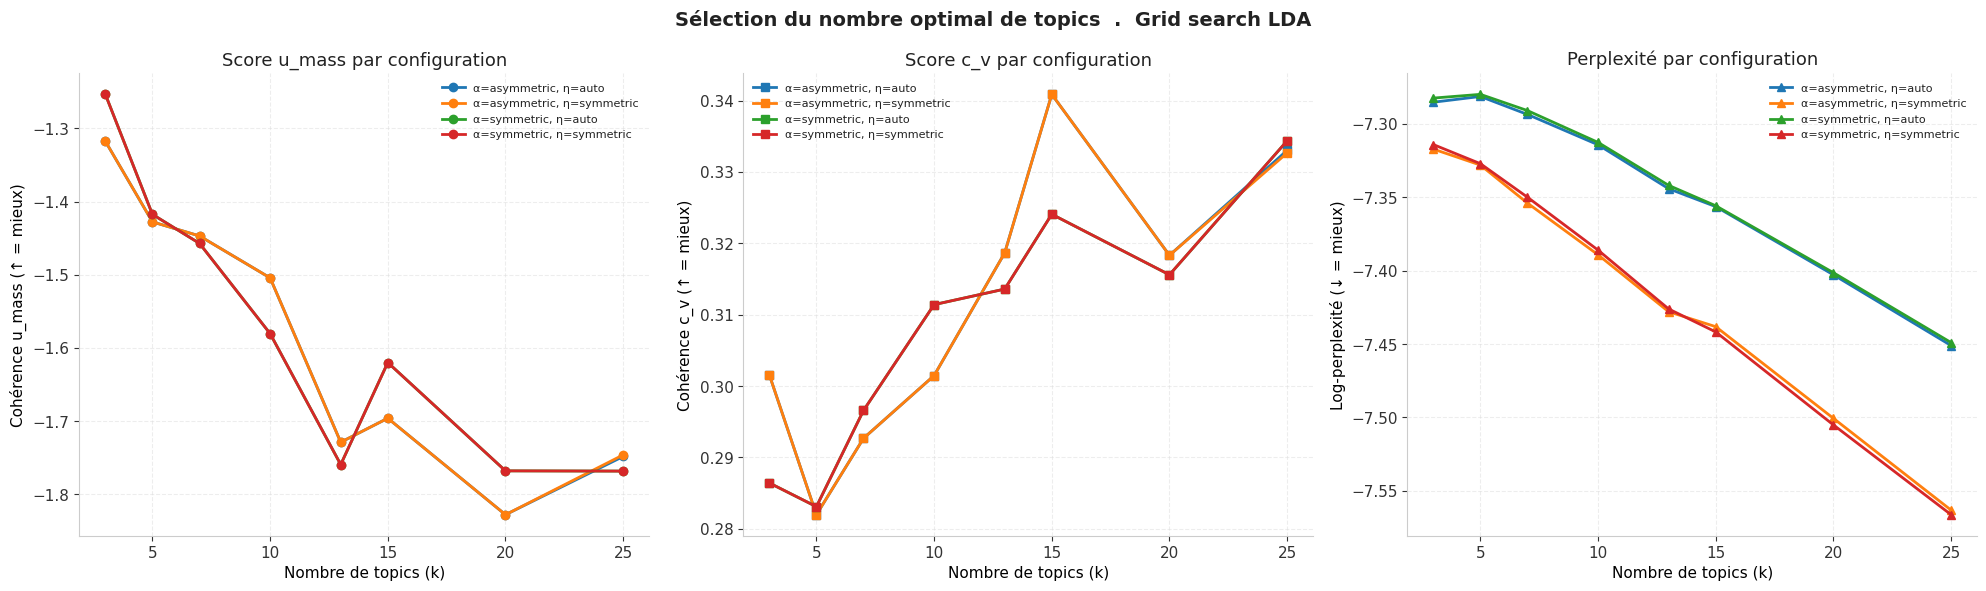


📋 Top 5 des configurations par cohérence u_mass :
 k      alpha       eta  coherence_umass  coherence_cv  perplexity
 3  symmetric symmetric        -1.253595      0.286414   -7.314135
 3  symmetric      auto        -1.253595      0.286414   -7.282487
 3 asymmetric symmetric        -1.317679      0.301562   -7.317218
 3 asymmetric      auto        -1.317679      0.301562   -7.285302
 5  symmetric symmetric        -1.417550      0.283091   -7.327165

📋 Top 5 des configurations par cohérence c_v :
 k      alpha       eta  coherence_umass  coherence_cv  perplexity
15 asymmetric      auto        -1.696019      0.340881   -7.356411
15 asymmetric symmetric        -1.696019      0.340881   -7.438190
25  symmetric      auto        -1.768211      0.334369   -7.449026
25  symmetric symmetric        -1.768211      0.334369   -7.566264
25 asymmetric      auto        -1.748274      0.333036   -7.451048


In [7]:
df_grid = pd.DataFrame(grid_results)

# --- Graphique 1 : Cohérence u_mass en fonction de k ---
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# u_mass par k (toutes configs confondues)
for (alpha, eta), grp in df_grid.groupby(['alpha', 'eta']):
    grp_sorted = grp.sort_values('k')
    axes[0].plot(grp_sorted['k'], grp_sorted['coherence_umass'],
                 marker='o', label=f"α={alpha}, η={eta}", linewidth=2)
axes[0].set_xlabel("Nombre de topics (k)")
axes[0].set_ylabel("Cohérence u_mass (↑ = mieux)")
axes[0].set_title("Score u_mass par configuration")
axes[0].legend(fontsize=8)
axes[0].grid(True, linestyle='--', alpha=0.5)

# c_v par k
for (alpha, eta), grp in df_grid.groupby(['alpha', 'eta']):
    grp_sorted = grp.sort_values('k')
    axes[1].plot(grp_sorted['k'], grp_sorted['coherence_cv'],
                 marker='s', label=f"α={alpha}, η={eta}", linewidth=2)
axes[1].set_xlabel("Nombre de topics (k)")
axes[1].set_ylabel("Cohérence c_v (↑ = mieux)")
axes[1].set_title("Score c_v par configuration")
axes[1].legend(fontsize=8)
axes[1].grid(True, linestyle='--', alpha=0.5)

# Perplexité par k
for (alpha, eta), grp in df_grid.groupby(['alpha', 'eta']):
    grp_sorted = grp.sort_values('k')
    axes[2].plot(grp_sorted['k'], grp_sorted['perplexity'],
                 marker='^', label=f"α={alpha}, η={eta}", linewidth=2)
axes[2].set_xlabel("Nombre de topics (k)")
axes[2].set_ylabel("Log-perplexité (↓ = mieux)")
axes[2].set_title("Perplexité par configuration")
axes[2].legend(fontsize=8)
axes[2].grid(True, linestyle='--', alpha=0.5)

plt.suptitle("Sélection du nombre optimal de topics  .  Grid search LDA", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Tableau des meilleurs résultats
print("\nTop 5 des configurations par cohérence u_mass :")
print(df_grid.sort_values('coherence_umass', ascending=False).head(5).to_string(index=False))
print("\nTop 5 des configurations par cohérence c_v :")
print(df_grid.sort_values('coherence_cv', ascending=False).head(5).to_string(index=False))

### A.7 Entraînement du modèle optimal

On sélectionne la meilleure configuration selon la cohérence u_mass (plus fiable que c_v pour les petits corpus, cf. Mimno et al. 2011). En cas de quasi-égalité, on préfère le modèle avec le moins de topics (parcimonie).

In [8]:

chemin_lda_model = os.path.join(DOSSIER_DATAFRAMES, "lda_best_model.pkl")
chemin_lda_dict = os.path.join(DOSSIER_DATAFRAMES, "lda_best_dict.pkl")

if os.path.exists(chemin_lda_model):
    lda_best = LdaModel.load(chemin_lda_model)
    dictionnaire = corpora.Dictionary.load(chemin_lda_dict)
    # Reconstruire le corpus avec le dictionnaire chargé
    corpus = [dictionnaire.doc2bow(doc) for doc in textes_pour_lda]
    best_config = df_grid.sort_values('coherence_umass', ascending=False).iloc[0]
    print(f"⏩ Meilleur modèle LDA chargé depuis le cache.")
    print(f"   k={int(best_config['k'])}, α={best_config['alpha']}, η={best_config['eta']}")
    print(f"   u_mass={best_config['coherence_umass']:.4f}, c_v={best_config['coherence_cv']:.4f}")
else:
    # Sélection de la meilleure configuration
    best_config = df_grid.sort_values('coherence_umass', ascending=False).iloc[0]
    best_k = int(best_config['k'])
    best_alpha = best_config['alpha']
    best_eta = best_config['eta']

    print(f"🏆 Meilleure configuration sélectionnée :")
    print(f"   k={best_k}, α={best_alpha}, η={best_eta}")
    print(f"   u_mass={best_config['coherence_umass']:.4f}, c_v={best_config['coherence_cv']:.4f}")
    print(f"\n🔄 Entraînement du modèle final (passes=30, iterations=400)...")

    # Entraînement avec plus de passes et d'itérations pour le modèle final
    lda_best = LdaMulticore(
        corpus=corpus,
        id2word=dictionnaire,
        num_topics=best_k,
        alpha=best_alpha,
        eta=best_eta,
        passes=30,
        iterations=400,
        random_state=42,
        chunksize=500,
        per_word_topics=True,
    )

    # Sauvegarde
    lda_best.save(chemin_lda_model)
    dictionnaire.save(chemin_lda_dict)
    print(f"💾 Modèle sauvegardé dans {chemin_lda_model}")

⏩ Meilleur modèle LDA chargé depuis le cache.
   k=3, α=symmetric, η=symmetric
   u_mass=-1.2536, c_v=0.2864


### A.8 Inspection qualitative des topics

L'évaluation quantitative (cohérence) doit toujours être complétée par une **inspection humaine**. On affiche les mots-clés de chaque topic et on vérifie que :
- Les topics sont **interprétables** (on peut leur donner un nom)
- Il n'y a pas de **redondance** (deux topics avec les mêmes mots)
- Les mots sont **spécifiques** au topic (pas des termes génériques)

In [9]:
# Affichage détaillé des topics avec cohérence individuelle
print("=" * 80)
print(f"TOPICS DU MODÈLE OPTIMAL (k={int(best_config['k'])})")
print("=" * 80)

# Cohérence par topic
topic_coherences = CoherenceModel(
    model=lda_best, texts=textes_pour_lda,
    dictionary=dictionnaire, coherence='u_mass',
    topn=10
).get_coherence_per_topic()

for topic_id in range(lda_best.num_topics):
    mots = lda_best.show_topic(topic_id, topn=12)
    mots_str = ", ".join([f"{mot} ({prob:.3f})" for mot, prob in mots])
    coherence_topic = topic_coherences[topic_id] if topic_id < len(topic_coherences) else float('nan')

    print(f"\n  Topic #{topic_id:2d} [cohérence={coherence_topic:+.4f}]")
    print(f"    {mots_str}")

TOPICS DU MODÈLE OPTIMAL (k=3)

  Topic # 0 [cohérence=-1.0537]
    travail (0.006), person (0.005), social (0.005), lutt_contr (0.005), comm (0.005), franc (0.005), fait (0.004), vis (0.004), cel (0.004), disposit (0.004), polit (0.003), autr (0.003)

  Topic # 1 [cohérence=-1.1282]
    femm (0.018), droit (0.014), enfant (0.011), franc (0.009), comm (0.008), cel (0.007), fait (0.007), homm (0.007), victim (0.006), elle (0.006), autr (0.004), ceux (0.004)

  Topic # 2 [cohérence=-1.0695]
    victim (0.011), droit (0.009), fait (0.007), person (0.007), comm (0.007), cel (0.006), vis (0.006), cas (0.005), san (0.004), peut (0.004), disposit (0.004), non (0.004)


### A.9 Heatmap de similarité inter-topics

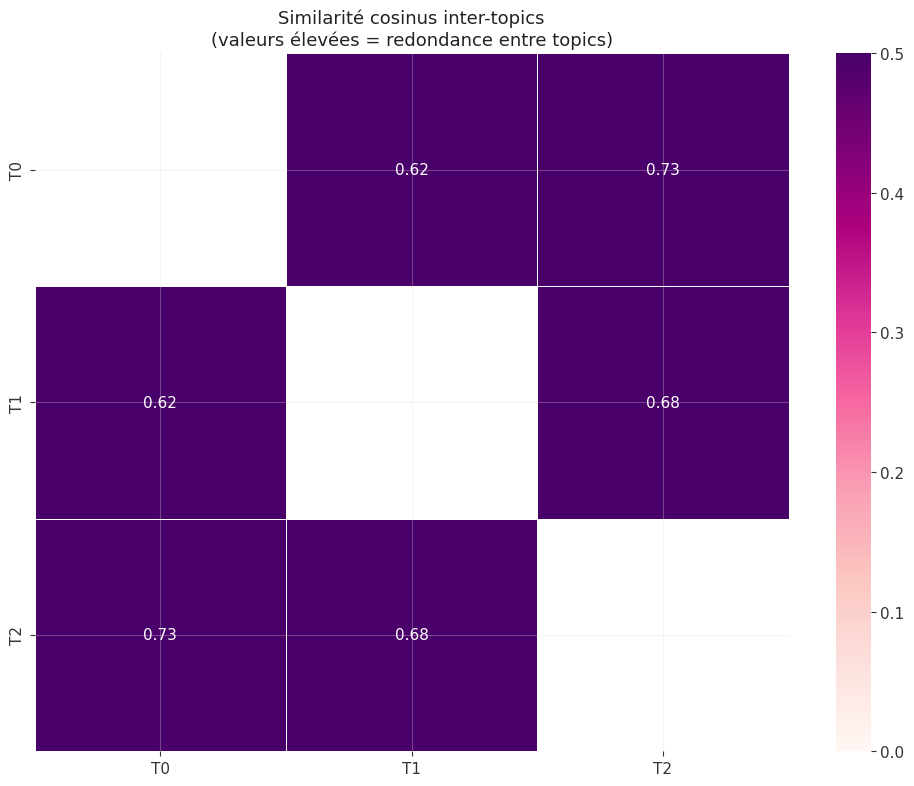

   ⚠️ Topics 0 et 1 possiblement redondants (sim=0.623)
   ⚠️ Topics 0 et 2 possiblement redondants (sim=0.729)
   ⚠️ Topics 1 et 2 possiblement redondants (sim=0.682)


In [10]:
from sklearn.metrics.pairwise import cosine_similarity as cos_sim

# Matrice topic-mot (chaque ligne = un topic, chaque colonne = un mot)
topic_word_matrix = lda_best.get_topics()  # shape: (n_topics, n_words)

# Similarité cosinus entre topics
sim_matrix = cos_sim(topic_word_matrix)

plt.figure(figsize=(10, 8))
mask = np.eye(sim_matrix.shape[0], dtype=bool)  # masquer la diagonale
sns.heatmap(
    sim_matrix, annot=True, fmt=".2f", cmap="RdPu",
    mask=mask, vmin=0, vmax=0.5,
    linewidths=0.5, linecolor='white',
    xticklabels=[f"T{i}" for i in range(sim_matrix.shape[0])],
    yticklabels=[f"T{i}" for i in range(sim_matrix.shape[0])],
)
plt.title("Similarité cosinus inter-topics\n(valeurs élevées = redondance entre topics)")
plt.tight_layout()
plt.show()

# Alerte si deux topics sont trop similaires
for i in range(sim_matrix.shape[0]):
    for j in range(i+1, sim_matrix.shape[1]):
        if sim_matrix[i, j] > 0.3:
            print(f"   Topics {i} et {j} possiblement redondants (sim={sim_matrix[i,j]:.3f})")

### A.10 Distribution des topics par bloc idéologique

On calcule pour chaque prise de parole la distribution sur les topics, puis on moyenne par bloc pour voir quels topics dominent dans quels blocs.

🔄 Calcul des distributions de topics par document...


Inférence: 100%|██████████| 7677/7677 [00:07<00:00, 980.03it/s] 


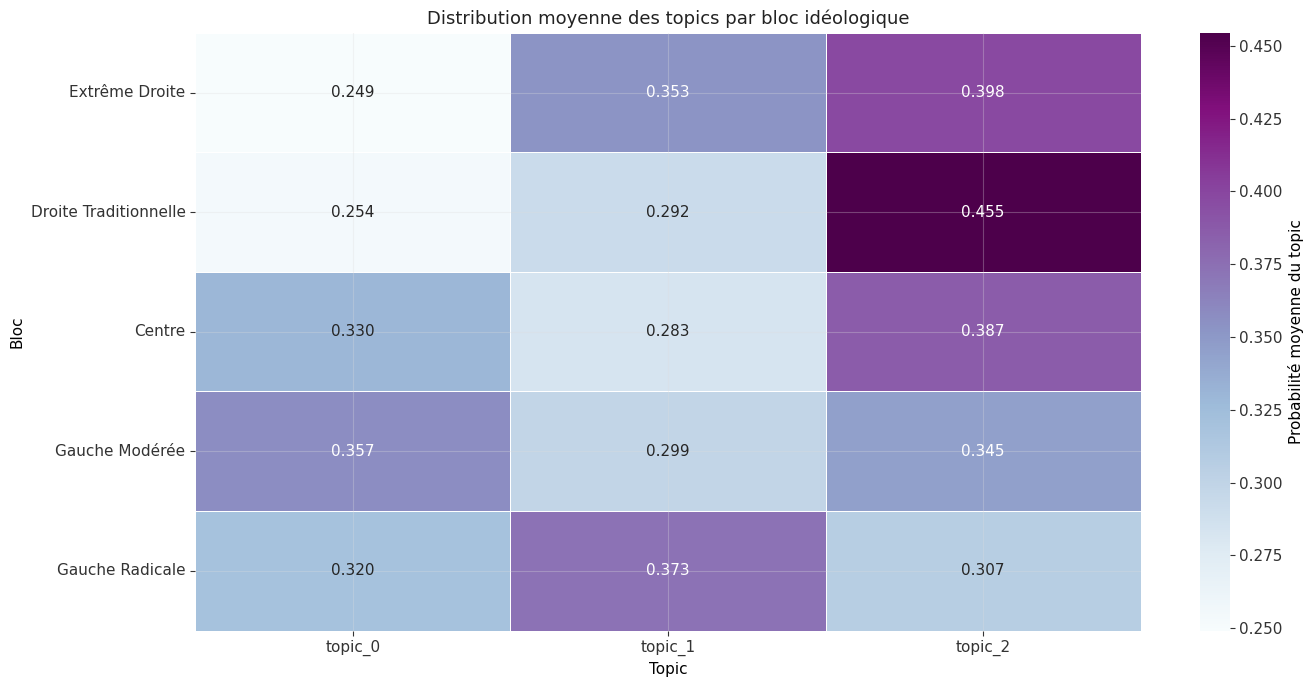

In [11]:
# Extraction de la distribution de topics pour chaque document
print("Calcul des distributions de topics par document...")

topic_distributions = []
for bow in tqdm(corpus, desc="Inférence"):
    doc_topics = lda_best.get_document_topics(bow, minimum_probability=0.0)
    probs = [0.0] * lda_best.num_topics
    for topic_id, prob in doc_topics:
        probs[topic_id] = prob
    topic_distributions.append(probs)

df_topics = pd.DataFrame(
    topic_distributions,
    columns=[f"topic_{i}" for i in range(lda_best.num_topics)]
)
df_topics['bloc'] = df_blocs['bloc'].values[:len(df_topics)]
df_topics['date'] = df_blocs['date'].values[:len(df_topics)]

# Moyenne par bloc
topic_cols = [f"topic_{i}" for i in range(lda_best.num_topics)]
moyennes_bloc = df_topics.groupby('bloc')[topic_cols].mean()
moyennes_bloc = moyennes_bloc.reindex([b for b in ORDRE_BLOCS if b in moyennes_bloc.index])

# Heatmap bloc × topic
plt.figure(figsize=(14, 7))
sns.heatmap(
    moyennes_bloc, annot=True, fmt=".3f", cmap="BuPu",
    linewidths=0.5, linecolor='white',
    cbar_kws={'label': 'Probabilité moyenne du topic'}
)
plt.title("Distribution moyenne des topics par bloc idéologique")
plt.xlabel("Topic")
plt.ylabel("Bloc")
plt.tight_layout()
plt.show()

### A.11 Évolution temporelle d'un topic spécifique

Après inspection des topics ci-dessus, on peut suivre l'évolution d'un topic d'intérêt (par exemple celui qui contient des termes liés à l'immigration/identité) au fil du temps et par bloc.

> **⚠️ Ajustez `TOPIC_A_SUIVRE`** après avoir lu les topics ci-dessus. Si aucun topic ne correspond clairement au cadrage identitaire, c'est un résultat en soi (la LDA ne capte pas ce signal).

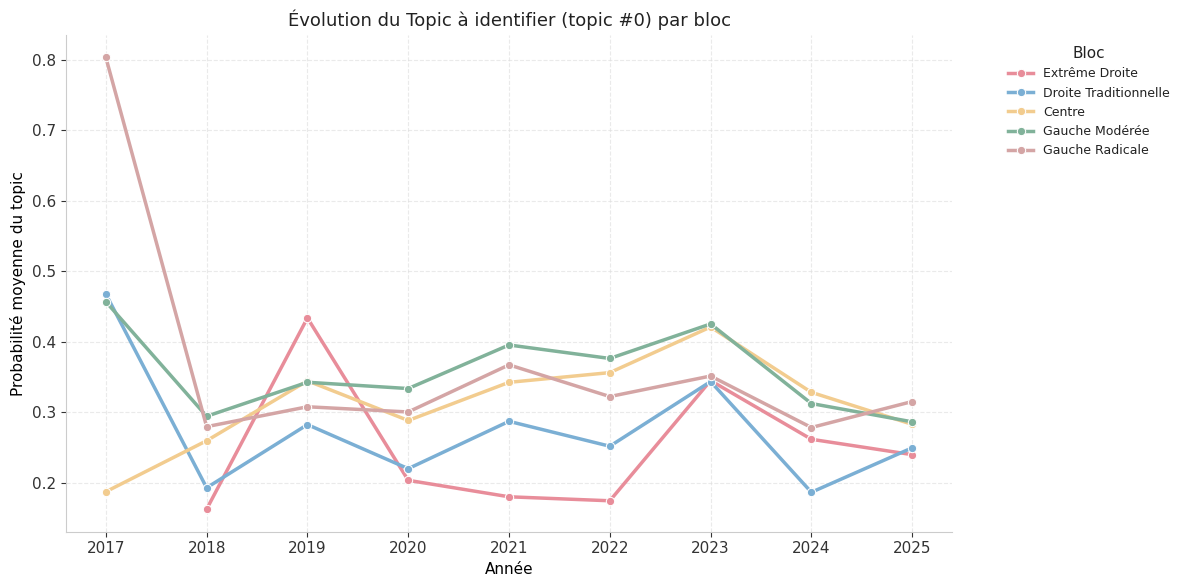

In [12]:
# --- PARAMÈTRE À AJUSTER APRÈS INSPECTION DES TOPICS ---
TOPIC_A_SUIVRE = 0  # ← Mettez ici le numéro du topic pertinent
NOM_TOPIC = "Topic à identifier"  # ← Donnez-lui un nom après inspection

# Évolution par année et par bloc
df_topics['annee'] = df_topics['date'].dt.to_period('Y').astype(str)
col_topic = f"topic_{TOPIC_A_SUIVRE}"

df_evol = df_topics.groupby(['annee', 'bloc'])[col_topic].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(
    data=df_evol, x='annee', y=col_topic,
    hue='bloc', hue_order=ORDRE_BLOCS,
    palette=COULEURS_BLOCS, marker='o', linewidth=2.5
)
plt.title(f"Évolution du {NOM_TOPIC} (topic #{TOPIC_A_SUIVRE}) par bloc")
plt.ylabel("Probabilité moyenne du topic")
plt.xlabel("Année")
plt.legend(title="Bloc", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

---
## Partie B  .  Embeddings CamemBERT et similarité cosinus
---

### B.1 Plongements contextuels avec CamemBERT

**Pourquoi CamemBERT plutôt que Word2Vec ?**
- Word2Vec produit un vecteur **statique** par mot (ignorant le contexte). "Viol" aura le même vecteur dans "viol de la loi" et "viol sexuel".
- CamemBERT (Martin et al. 2020) est un modèle Transformer pré-entraîné sur 138 Go de texte français. Il produit un vecteur **contextuel** de 768 dimensions pour chaque token, capturant le sens en contexte.

On utilise le vecteur **CLS** (première position) comme représentation du document entier, ce qui est standard pour les tâches de classification/similarité de texte.


In [13]:

import subprocess, sys
try:
    import torch
    from transformers import CamembertTokenizer, CamembertModel
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q",
                           "torch", "transformers", "sentencepiece"])
    import torch
    from transformers import CamembertTokenizer, CamembertModel

print(f"PyTorch disponible. GPU : {torch.cuda.is_available()}")

✅ PyTorch disponible. GPU : False


In [14]:
# ==========================================================================

CHEMIN_DF_EMBEDDINGS = "/home/onyxia/work/projet_eco_socio/df_vss_embeddings.pkl"
if os.path.exists(CHEMIN_DF_EMBEDDINGS):
    df_blocs = pd.read_pickle(CHEMIN_DF_EMBEDDINGS)
    print(f"Embeddings chargés depuis le cache : {len(df_blocs)} prises de parole.")
else:
    print("Encodage CamemBERT de toutes les prises de parole...")
    print("   (cela peut prendre 30-60 min sur CPU)\n")

    device = "cuda" if torch.cuda.is_available() else "cpu"
    tokenizer = CamembertTokenizer.from_pretrained("camembert-base")
    model_camembert = CamembertModel.from_pretrained("camembert-base").to(device)
    model_camembert.eval()

    def encode_texte(texte):
        inputs = tokenizer(
            str(texte), return_tensors="pt",
            truncation=True, padding=True, max_length=512
        ).to(device)
        with torch.no_grad():
            outputs = model_camembert(**inputs)
        return outputs.last_hidden_state[:, 0, :].squeeze().cpu().numpy()

    tqdm.pandas(desc="CamemBERT")
    df_blocs['vecteur'] = df_blocs['texte'].progress_apply(encode_texte)

    df_blocs.to_pickle(CHEMIN_DF_EMBEDDINGS)
    print(f"\n💾 Sauvegardé dans {CHEMIN_DF_EMBEDDINGS}")

🔄 Encodage CamemBERT de toutes les prises de parole...
   (cela peut prendre 30-60 min sur CPU)



tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/811k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/508 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/445M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

CamembertModel LOAD REPORT from: camembert-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.bias              | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
CamemBERT: 100%|██████████| 7677/7677 [56:28<00:00,  2.27it/s]  



💾 Sauvegardé dans /home/onyxia/work/projet_eco_socio/df_vss_embeddings.pkl


### B.2 Similarité cosinus entre blocs et extrême droite

Pour chaque année, on calcule le **centroïde** (vecteur moyen) de chaque bloc, puis la similarité cosinus entre chaque centroïde et celui de l'extrême droite. Si un bloc se rapproche sémantiquement de l'ED au fil du temps, sa courbe monte.

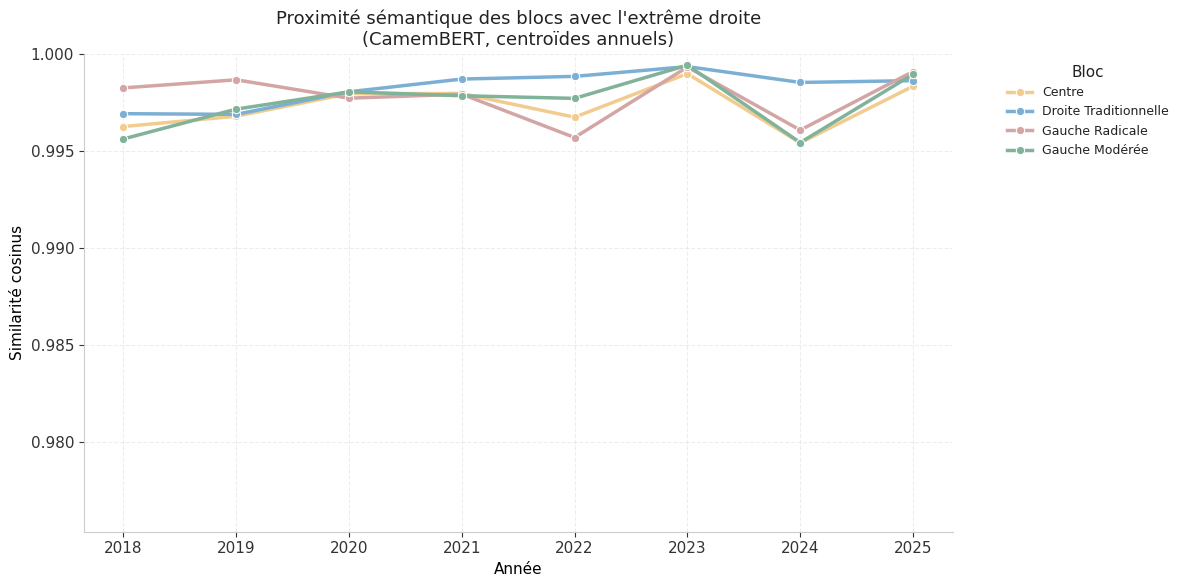

In [15]:
from sklearn.metrics.pairwise import cosine_similarity

df_blocs['annee'] = df_blocs['date'].dt.to_period('Y').astype(str)

resultats_sim = []
for annee in sorted(df_blocs['annee'].unique()):
    df_an = df_blocs[df_blocs['annee'] == annee]

    if "Extrême Droite" not in df_an['bloc'].values:
        continue

    vecs_ed = np.vstack(df_an[df_an['bloc'] == "Extrême Droite"]['vecteur'].values)
    centroid_ed = np.mean(vecs_ed, axis=0)

    for bloc in df_an['bloc'].unique():
        if bloc == "Extrême Droite":
            continue
        vecs = np.vstack(df_an[df_an['bloc'] == bloc]['vecteur'].values)
        centroid = np.mean(vecs, axis=0)
        sim = cosine_similarity([centroid_ed], [centroid])[0][0]
        resultats_sim.append({'annee': annee, 'bloc': bloc, 'similarite': sim})

df_sim = pd.DataFrame(resultats_sim)

palette = {"Droite Traditionnelle": "#7BAFD4", "Centre": "#F2CC8F",
           "Gauche Modérée": "#81B29A", "Gauche Radicale": "#D4A5A5"}

plt.figure(figsize=(12, 6))
sns.lineplot(data=df_sim, x='annee', y='similarite', hue='bloc',
             palette=palette, marker='o', linewidth=2.5)
plt.title("Proximité sémantique des blocs avec l'extrême droite\n(CamemBERT, centroïdes annuels)")
plt.ylabel("Similarité cosinus")
plt.xlabel("Année")
plt.legend(title="Bloc", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.ylim(df_sim['similarite'].min() - 0.02, 1.0)
plt.tight_layout()
plt.show()

### B.3 Convergence vers le concept "immigration/identité"

On crée un **vecteur de référence** représentant le concept "immigration + identité nationale" en encodant une phrase-concept avec CamemBERT, puis on mesure la similarité de chaque bloc avec ce vecteur au fil du temps.

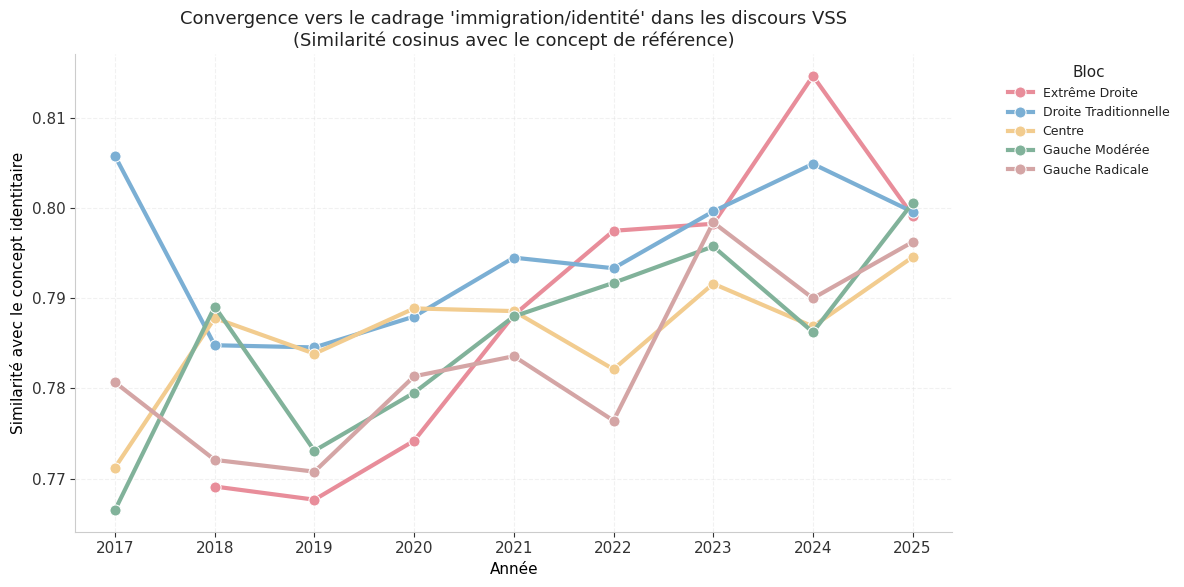

In [16]:
# Création du vecteur concept
phrase_concept = (
    "immigration clandestin frontière étranger identité nationale "
    "culture expulsion OQTF territoire islam intégration"
)

if 'encode_texte' not in dir():
    device = "cuda" if torch.cuda.is_available() else "cpu"
    tokenizer = CamembertTokenizer.from_pretrained("camembert-base")
    model_c = CamembertModel.from_pretrained("camembert-base").to(device)
    model_c.eval()
    def encode_texte(texte):
        inputs = tokenizer(str(texte), return_tensors="pt", truncation=True, padding=True, max_length=512).to(device)
        with torch.no_grad():
            outputs = model_c(**inputs)
        return outputs.last_hidden_state[:, 0, :].squeeze().cpu().numpy()

vecteur_concept = encode_texte(phrase_concept)

# Mesure de proximité
df_blocs['prox_concept'] = df_blocs['vecteur'].apply(
    lambda x: cosine_similarity([x], [vecteur_concept])[0][0]
)

df_derive = df_blocs.groupby(['annee', 'bloc'])['prox_concept'].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(
    data=df_derive, x='annee', y='prox_concept',
    hue='bloc', hue_order=ORDRE_BLOCS,
    palette=COULEURS_BLOCS, marker='o', linewidth=3, markersize=8
)
plt.title("Convergence vers le cadrage 'immigration/identité' dans les discours VSS\n(Similarité cosinus avec le concept de référence)")
plt.ylabel("Similarité avec le concept identitaire")
plt.xlabel("Année")
plt.legend(title="Bloc", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

---
## Références méthodologiques

- **Blei, D. M., Ng, A. Y., & Jordan, M. I.** (2003). Latent Dirichlet Allocation. *Journal of Machine Learning Research*, 3, 993–1022.
- **Mimno, D., Wallach, H. M., Talley, E., Leenders, M., & McCallum, A.** (2011). Optimizing Semantic Coherence in Topic Models. *EMNLP*.
- **Röder, M., Both, A., & Hinneburg, A.** (2015). Exploring the Space of Topic Coherence Measures. *WSDM*.
- **Martin, L., et al.** (2020). CamemBERT: a Tasty French Language Model. *ACL*.
- **Schofield, A., Magnusson, M., & Mimno, D.** (2017). Pulling Out the Stops: Rethinking Stopword Removal for Topic Models. *EACL*.